In [1]:
#RUN THIS BEFORE IMPORTING pycaret
!python3 -m pip install --upgrade pip setuptools wheel "Cython<3"
!python3 -m pip install --upgrade blinker --ignore-installed
!python3 -m pip install git+https://github.com/pycaret/pycaret.git@master --upgrade
exit() #Same as doing "Runtime -> Restart session"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 18.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 19.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 83.6 MB/s eta 0:00:00
  Attempting uninstall: setuptools
    Found existing installation: setuptools 75.2.0
    Uninstalling setuptools-75.2.0:
      Successfully uninstalled setuptools-75.2.0
  Attempting uninstall: pip
    Found existing installation: pip 24.1.2
    Uninstalling pip-24.1.2:
      Successfully uninstalled pip-24.1.2
  Attempting uninstall: Cython
    Found existing installation: Cython 3.0.12
    Uninstalling Cython-3.0.12:
      Successfully uninstalled Cython-3.0.12
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ipython 7.34.0 requires jedi>=0.16, which is not installed.
  Cloning https://github.com/pycaret/pycaret.git (to revision mas

In [1]:
import pycaret
from pycaret.regression import *
from pycaret.datasets import get_data

In [3]:
dataset = get_data('insurance')
dataset.head()
dataset.shape

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


(1338, 7)

In [4]:
data = dataset.sample(frac=0.9, random_state=786)
data_unseen = dataset.drop(data.index)

data.reset_index(drop=True, inplace=True)
data_unseen.reset_index(drop=True, inplace=True)

print('Data for Modeling:', data.shape)
print('Unseen Data:', data_unseen.shape)

Data for Modeling: (1204, 7)
Unseen Data: (134, 7)


In [6]:
s = setup(
    data=data,
    target='charges',
    train_size=0.7,
    session_id=123
)

,Description,Value
0,Session id,123
1,Target,charges
2,Target type,Regression
3,Original data shape,"(1204, 7)"
4,Transformed data shape,"(1204, 10)"
5,Transformed train set shape,"(842, 10)"
6,Transformed test set shape,"(362, 10)"
7,Numeric features,3
8,Categorical features,3
9,Preprocess,True


In [7]:
compare_models(include=['ridge', 'knn'], sort='RMSE')
ridge = create_model('ridge')
knn   = create_model('knn')

,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
ridge,Ridge Regression,4203.5881,35521087.9039,5935.8918,0.7487,0.5780,0.4377,0.5830
knn,K Neighbors Regressor,8375.6199,138211371.2000,11674.4912,0.0736,0.8535,0.9570,0.0590


Processing:   0%|          | 0/13 [00:00<?, ?it/s]

,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,4182.1373,35401077.9684,5949.8805,0.7744,0.7602,0.4592
1,3944.9433,26452404.4226,5143.1901,0.8601,0.4062,0.4534
2,4296.4480,32290104.5761,5682.4383,0.7499,0.4943,0.4421
3,4214.2585,40596824.1914,6371.5637,0.6500,0.7534,0.4214
4,4590.5067,43949373.4255,6629.4324,0.7219,0.5548,0.3331
5,3688.4829,26539533.9107,5151.6535,0.8154,0.4165,0.3790
6,4823.6582,42493624.0333,6518.7134,0.7665,0.5975,0.4448
7,3919.1805,35806862.8576,5983.8836,0.6652,0.6610,0.4670
8,4180.0979,29639387.8983,5444.2068,0.8536,0.4925,0.5194


Processing:   0%|          | 0/4 [00:00<?, ?it/s]

,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,9552.0674,178585424.0000,13363.5859,-0.1378,0.8988,0.9914
1,9865.5186,197346112.0000,14047.9932,-0.0438,0.9772,1.2073
2,8760.4131,137919920.0000,11743.9316,-0.0681,0.9138,1.0749
3,6846.1108,90265640.0000,9500.8232,0.2219,0.7623,0.7492
4,8637.8623,143507536.0000,11979.4629,0.0918,0.8503,0.7107
5,7336.7485,116570696.0000,10796.7910,0.1892,0.7169,0.7892
6,8991.7021,158908032.0000,12605.8730,0.1267,0.8161,0.8060
7,7833.9971,101164992.0000,10058.0811,0.0540,0.9226,1.3104
8,8535.1631,147674544.0000,12152.1416,0.2707,0.8448,0.9717


Processing:   0%|          | 0/4 [00:00<?, ?it/s]

In [8]:
ridge_grid = {'alpha': [0, 0.2, 0.4, 0.6, 0.8, 1, 2]}

tuned_ridge = tune_model(
    ridge,
    custom_grid=ridge_grid,
    optimize='RMSE'
)

,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,4087.9964,34924842.6908,5909.7244,0.7775,0.6311,0.4479
1,3915.3887,26254135.8245,5123.8790,0.8611,0.4033,0.4496
2,4281.6308,32311721.7154,5684.3400,0.7498,0.4912,0.4397
3,4213.6475,40823034.0397,6389.2906,0.6481,0.8955,0.4206
4,4585.7908,44147129.9552,6644.3307,0.7206,0.5562,0.3323
5,3715.9493,26569697.5475,5154.5802,0.8152,0.4346,0.3804
6,4802.5453,42389350.7164,6510.7105,0.7670,0.6288,0.4430
7,3906.8992,35940181.0359,5995.0130,0.6639,0.6901,0.4629
8,4183.9998,29645620.0095,5444.7792,0.8536,0.4873,0.5155


Processing:   0%|          | 0/7 [00:00<?, ?it/s]

Fitting 10 folds for each of 7 candidates, totalling 70 fits


In [9]:
knn_grid = {'n_neighbors': [3, 5, 7, 9, 11]}

tuned_knn = tune_model(
    knn,
    custom_grid=knn_grid,
    optimize='RMSE'
)

,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,8867.7422,151193216.0000,12296.0654,0.0367,0.8734,0.9534
1,10118.6357,185894992.0000,13634.3311,0.0168,0.9241,1.1145
2,8842.4551,122333576.0000,11060.4512,0.0526,0.8742,1.0566
3,7098.5430,89423752.0000,9456.4131,0.2291,0.7460,0.8173
4,8861.6982,132511232.0000,11511.3525,0.1614,0.8203,0.7855
5,8012.0928,119532848.0000,10933.1074,0.1685,0.7968,0.9685
6,9307.3906,157677024.0000,12556.9512,0.1334,0.7610,0.8269
7,7625.0166,92820416.0000,9634.3350,0.1320,0.9040,1.2683
8,9403.5547,159976000.0000,12648.1621,0.2100,0.8934,1.1591


Processing:   0%|          | 0/7 [00:00<?, ?it/s]

Fitting 10 folds for each of 5 candidates, totalling 50 fits


,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE
0,Ridge Regression,4224.0717,38153626.3704,6176.8622,0.7109,0.5632,0.4516


,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE
0,K Neighbors Regressor,8079.7617,116752408.0000,10805.2031,0.1153,0.8195,0.9870


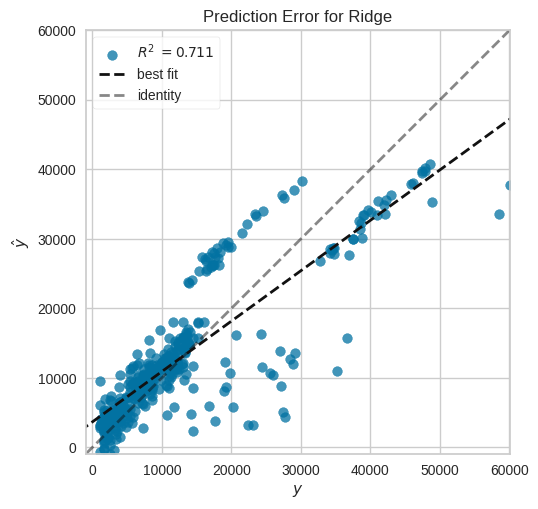

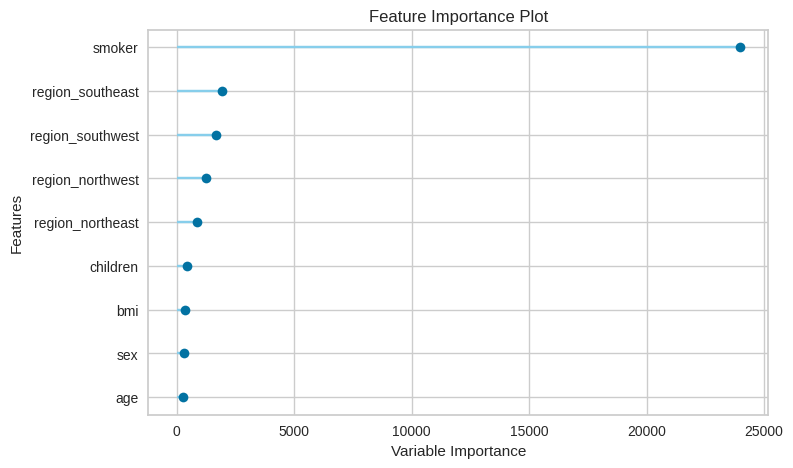

In [10]:
predict_model(tuned_ridge)
predict_model(tuned_knn)
plot_model(tuned_ridge, plot='error')
plot_model(tuned_ridge, plot='feature')

In [11]:
final_model = finalize_model(tuned_ridge)

In [12]:
unseen_predictions = predict_model(final_model, data=data_unseen)
unseen_predictions.head()

,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE
0,Ridge Regression,4456.0355,44719846.3410,6687.2899,0.7071,0.5908,0.3454


,age,sex,bmi,children,smoker,region,charges,prediction_label
0,31,female,25.740000,0,no,southeast,3756.621582,3702.382608
1,37,female,27.740000,3,no,northwest,7281.505371,8145.747978
2,56,female,39.820000,0,no,southeast,11090.717773,15050.971456
3,23,male,23.844999,0,no,northeast,2395.171631,1816.597367
4,19,female,28.600000,5,no,southwest,4687.796875,4359.326047


In [13]:
save_model(final_model, 'Final_Ridge_Model')
loaded_model = load_model('Final_Ridge_Model')

Transformation Pipeline and Model Successfully Saved
Transformation Pipeline and Model Successfully Loaded


,Relative Compactness,Surface Area,Wall Area,Roof Area,Overall Height,Orientation,Glazing Area,Glazing Area Distribution,Heating Load,Cooling Load
0,0.98,514.5,294.0,110.25,7.0,2,0.0,0,15.55,21.33
1,0.98,514.5,294.0,110.25,7.0,3,0.0,0,15.55,21.33
2,0.98,514.5,294.0,110.25,7.0,4,0.0,0,15.55,21.33
3,0.98,514.5,294.0,110.25,7.0,5,0.0,0,15.55,21.33
4,0.90,563.5,318.5,122.50,7.0,2,0.0,0,20.84,28.28


,Description,Value
0,Session id,123
1,Target,Heating Load
2,Target type,Regression
3,Original data shape,"(691, 10)"
4,Transformed data shape,"(691, 10)"
5,Transformed train set shape,"(483, 10)"
6,Transformed test set shape,"(208, 10)"
7,Numeric features,9
8,Preprocess,True
9,Imputation type,simple


,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,1.2534,3.1911,1.7864,0.9697,0.0614,0.0518
1,1.3072,3.8984,1.9744,0.9724,0.0775,0.0627
2,0.8706,1.3742,1.1722,0.9826,0.0515,0.0440
3,1.3757,3.5261,1.8778,0.9515,0.0777,0.0659
4,1.3763,4.5861,2.1415,0.9522,0.0729,0.0565
5,1.2479,4.3367,2.0825,0.9523,0.0687,0.0516
6,1.4638,3.8694,1.9671,0.9576,0.0871,0.0716
7,1.0960,2.1854,1.4783,0.9757,0.0635,0.0550
8,1.0607,2.3472,1.5320,0.9789,0.0661,0.0513


Processing:   0%|          | 0/4 [00:00<?, ?it/s]

,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,1.1217,2.6396,1.6247,0.9749,0.0566,0.0459
1,1.3342,3.6116,1.9004,0.9744,0.1298,0.0972
2,1.1492,3.4964,1.8699,0.9558,0.1042,0.0692
3,1.4097,4.8870,2.2107,0.9328,0.0945,0.0694
4,1.1027,5.6658,2.3803,0.9409,0.0805,0.0485
5,0.8891,1.7451,1.3210,0.9808,0.0528,0.0437
6,1.4872,7.9571,2.8208,0.9129,0.1032,0.0677
7,1.0843,2.2722,1.5074,0.9747,0.0880,0.0666
8,1.1218,2.7519,1.6589,0.9752,0.0742,0.0547


...

Processing:   0%|          | 0/7 [00:00<?, ?it/s]

Fitting 10 folds for each of 9 candidates, totalling 90 fits


,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,1.1052,2.7047,1.6446,0.9743,0.0569,0.0448
1,1.0319,2.2794,1.5098,0.9839,0.1010,0.0727
2,1.0606,3.2356,1.7988,0.9591,0.0941,0.0631
3,1.3475,4.5242,2.1270,0.9378,0.0924,0.0674
4,1.1231,6.2370,2.4974,0.9350,0.0824,0.0477
5,0.7982,1.6268,1.2755,0.9821,0.0499,0.0385
6,1.4567,7.9573,2.8209,0.9129,0.0995,0.0635
7,1.0376,2.2999,1.5165,0.9744,0.0806,0.0584
8,0.9444,1.8362,1.3551,0.9835,0.0569,0.0434


Processing:   0%|          | 0/7 [00:00<?, ?it/s]

Fitting 10 folds for each of 5 candidates, totalling 50 fits


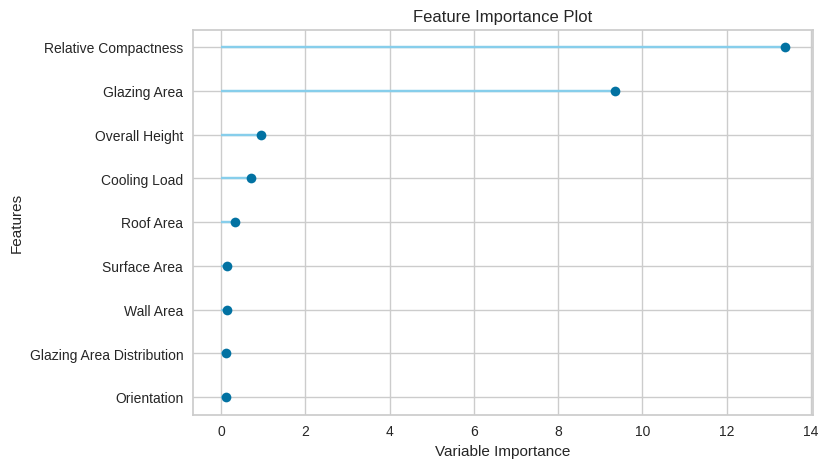

In [14]:
dataset = get_data('energy')

data = dataset.sample(frac=0.9, random_state=123)
data_unseen = dataset.drop(data.index)

s = setup(
    data=data,
    target='Heating Load',
    session_id=123
)

ridge = create_model('ridge')
knn = create_model('knn')

tuned_ridge = tune_model(
    ridge,
    custom_grid={'alpha':[0,0.1,0.3,0.5,0.7,1,2,4,8]},
    optimize='RMSE'
)

tuned_knn = tune_model(
    knn,
    custom_grid={'n_neighbors':[3,5,7,9,11]},
    optimize='RMSE'
)

plot_model(tuned_ridge, plot='feature')